In [217]:
import random as rn

network = {
    "x1": rn.random(),
    "x2": rn.random(),
    "w13": rn.random(),
    "w14": rn.random(),
    "w23": rn.random(),
    "w24": rn.random(),
    "w35": rn.random(),
    "w45": rn.random(),
    "b3": rn.random(),
    "b4": rn.random(),
    "b5": rn.random(),
}

In [218]:
x5_target=1

In [219]:
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [220]:
def gradient_decent(learning_rate,del_j,xi):
    return learning_rate*del_j*xi

In [221]:
def bias_change(learning_rate,del_j,b_old):
    return b_old+learning_rate*del_j;

In [222]:
import matplotlib.pyplot as plt

def train(network,learning_rate):

    bu=0
    max_cycle=10000000000
    history=[]

    for i in range(max_cycle):
        x1=network["x1"]
        x2=network["x2"]
        w13=network["w13"]
        w14=network["w14"]
        w23=network["w23"]
        w24=network["w24"]
        w35=network["w35"]
        w45=network["w45"]

        b3=network["b3"]
        b4=network["b4"]
        b5=network["b5"]

        x3=network["x3"]=sigmoid(x1*w13+x2*w23+b3)
        x4=network["x4"]=sigmoid(x1*w14+x2*w24+b4)
        x5=network["x5"]=sigmoid(x3*w35+x4*w45+b5)

        # Error
        err=x5_target-x5
        history.append(abs(err))

        if(abs(err)<0.01):
            # print("Number of cycles of learning rate ",learning_rate," : ",i) 
            bu=1 
            break

        del_5=x5*(1-x5)*(x5_target-x5)
        del_4=x4*(1-x4)*w45*del_5
        del_3=x3*(1-x3)*w35*del_5
    
        del_w45=gradient_decent(learning_rate,del_5,x4)
        del_w35=gradient_decent(learning_rate,del_5,x3)
        del_w13=gradient_decent(learning_rate,del_3,x1)
        del_w14=gradient_decent(learning_rate,del_4,x1)
        del_w23=gradient_decent(learning_rate,del_3,x2)
        del_w24=gradient_decent(learning_rate,del_4,x2)

        network["w45"]=w45+del_w45
        network["w35"]=w35+del_w35
        network["w13"]=w13+del_w13
        network["w14"]=w14+del_w14
        network["w23"]=w23+del_w23
        network["w24"]=w24+del_w24

        network["b3"]=bias_change(learning_rate,del_3,b3)
        network["b4"]=bias_change(learning_rate,del_4,b4)
        network["b5"]=bias_change(learning_rate,del_5,b5)

    # if not bu:
    #     print("Max Limit reached")

    return i+1,x5,history


Learning rate: 0.1, cycles: 21372, output: 0.9900
Learning rate: 0.2, cycles: 10686, output: 0.9900
Learning rate: 0.3, cycles: 7123, output: 0.9900
Learning rate: 0.4, cycles: 5342, output: 0.9900
Learning rate: 0.5, cycles: 4274, output: 0.9900
Learning rate: 0.6, cycles: 3561, output: 0.9900
Learning rate: 0.7, cycles: 3052, output: 0.9900
Learning rate: 0.8, cycles: 2671, output: 0.9900
Learning rate: 0.9, cycles: 2374, output: 0.9900
Learning rate: 1.0, cycles: 2136, output: 0.9900


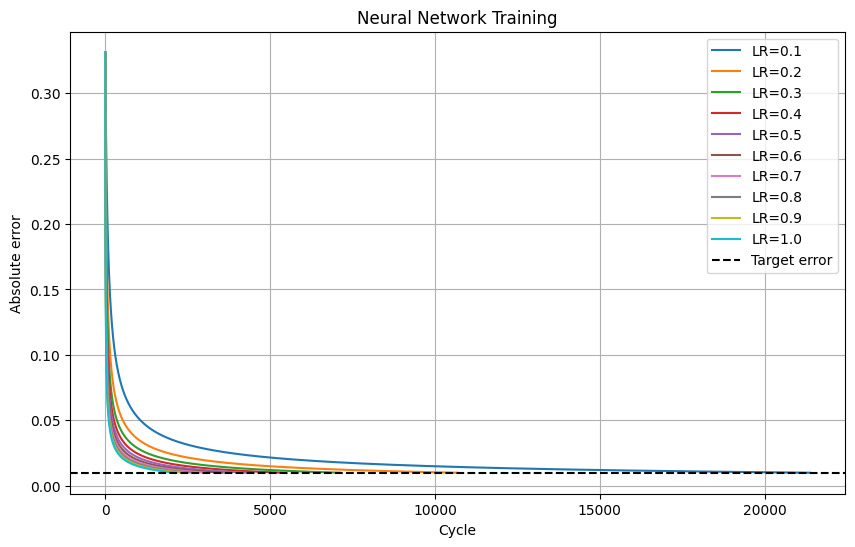

In [223]:
# train(network)
import copy

network_main=copy.deepcopy(network)
results={}

for learning_rate in np.arange(0.1,1.1,0.1):
    network=copy.deepcopy(network_main)
    cycles,output,history=train(network,learning_rate)
    results[learning_rate]=(cycles,output,history)

    print(
        f"Learning rate: {learning_rate:.1f}, "
        f"cycles: {cycles}, output: {output:.4f}"
    )

# for key,value in network.items():
#     print(key," - ",value)


plt.figure(figsize=(10, 6))

for learning_rate, (_, _, history) in results.items():
    plt.plot(history, label=f"LR={learning_rate:.1f}")

plt.axhline(0.01, color="black", linestyle="--", label="Target error")
plt.xlabel("Cycle")
plt.ylabel("Absolute error")
plt.title("Neural Network Training")
plt.legend()
plt.grid()
plt.show()